In [21]:
#import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt2
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



In [3]:
df1 = pd.read_csv('firstrealFinal.csv', usecols=[0,1,2,3,4])
df2 = pd.read_csv('secondrealFinal.csv', usecols=[0,1,2,3,4])
cols =  ["time", "rsp", "ppg", "ecg","eda"]
df1.columns = cols
df2.columns = cols
print(df1.head())
print(df2.head())

arr1 = df1.to_numpy()
arr2 = df2.to_numpy()


     time      rsp       ppg       ecg       eda
0  0.0005  5.32043 -0.014343 -0.004730 -0.004578
1  0.0010  5.32104 -0.014648 -0.004883 -0.003052
2  0.0015  5.31982 -0.014648 -0.004730 -0.003052
3  0.0020  5.32013 -0.014648 -0.004883 -0.004578
4  0.0025  5.32013 -0.014648 -0.004883 -0.004578
     time      rsp       ppg       ecg           eda
0  0.0005  6.25854  0.336914  0.058289  1.526070e-03
1  0.0010  6.25854  0.336304  0.059357  1.526070e-03
2  0.0015  6.25885  0.333862  0.060272  1.526070e-03
3  0.0020  6.25885  0.332336  0.060883  3.051940e-03
4  0.0025  6.25885  0.332031  0.060730  1.862670e-07


In [4]:
arr1time = arr1[:,0]
arr1rsp = arr1[:,1]
arr1ppg = arr1[:,2]
arr1ecg = arr1[:,3]
arr1eda = arr1[:,4]

arr2time = arr2[:,0]
arr2rsp = arr2[:,1]
arr2ppg = arr2[:,2]
arr2ecg = arr2[:,3]
arr2eda = arr2[:,4]

print(arr1time)
print(arr2time)

[5.00000e-04 1.00000e-03 1.50000e-03 ... 1.63326e+02 1.63327e+02
 1.63327e+02]
[5.00000e-04 1.00000e-03 1.50000e-03 ... 1.64798e+02 1.64799e+02
 1.64799e+02]


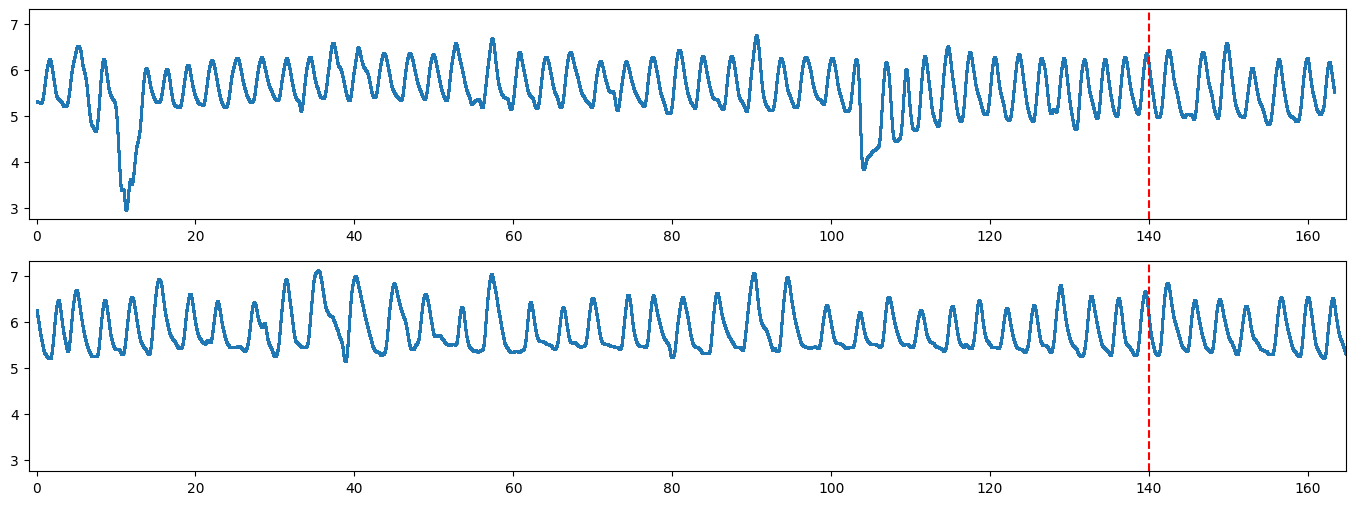

In [5]:
ymin = min(arr1rsp.min(), arr2rsp.min()) - 0.2
ymax = max(arr1rsp.max(), arr2rsp.max()) +0.2

plt.figure(figsize=(17, 6))

plt.subplot(2, 1, 1)
plt.scatter(arr1time, arr1rsp, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')


plt.subplot(2, 1, 2)
plt.scatter(arr2time, arr2rsp, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')

plt.show()

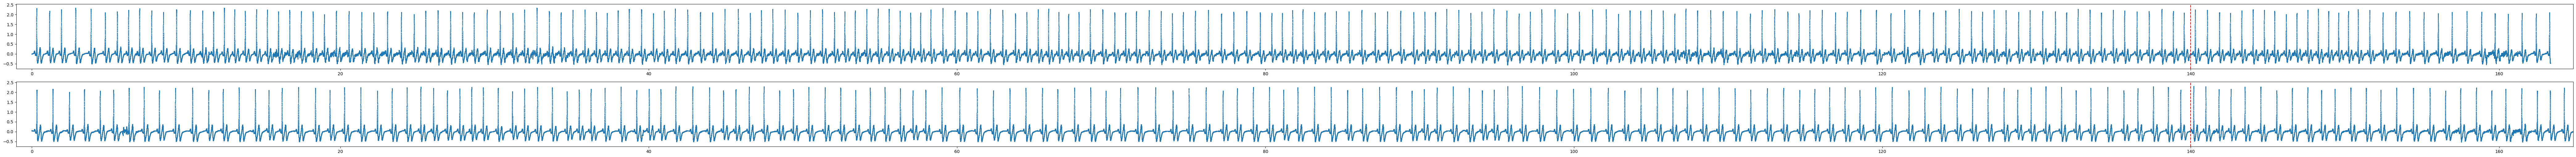

In [15]:
ymin = min(arr1ecg.min(), arr2ecg.min()) - 0.2
ymax = max(arr1ecg.max(), arr2ecg.max()) +0.2

plt.figure(figsize=(107, 6))

plt.subplot(2, 1, 1)
plt.scatter(arr1time, arr1ecg, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')


plt.subplot(2, 1, 2)
plt.scatter(arr2time, arr2ecg, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')

plt.show()

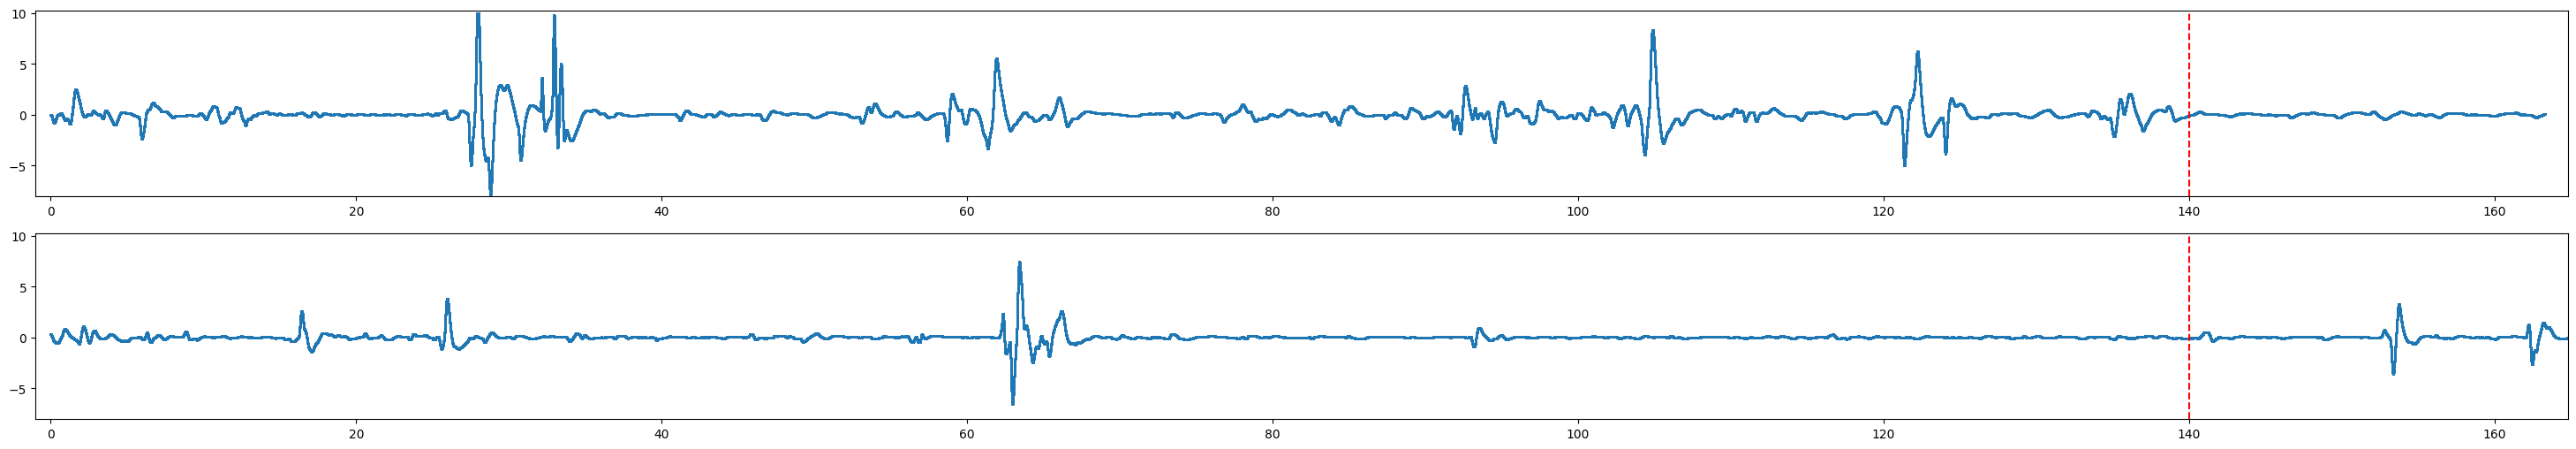

In [14]:
ymin = min(arr1ppg.min(), arr2ppg.min()) - 0.2
ymax = max(arr1ppg.max(), arr2ppg.max()) +0.2

plt.figure(figsize=(37, 6))

plt.subplot(2, 1, 1)
plt.scatter(arr1time, arr1ppg, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')


plt.subplot(2, 1, 2)
plt.scatter(arr2time, arr2ppg, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')

plt.show()

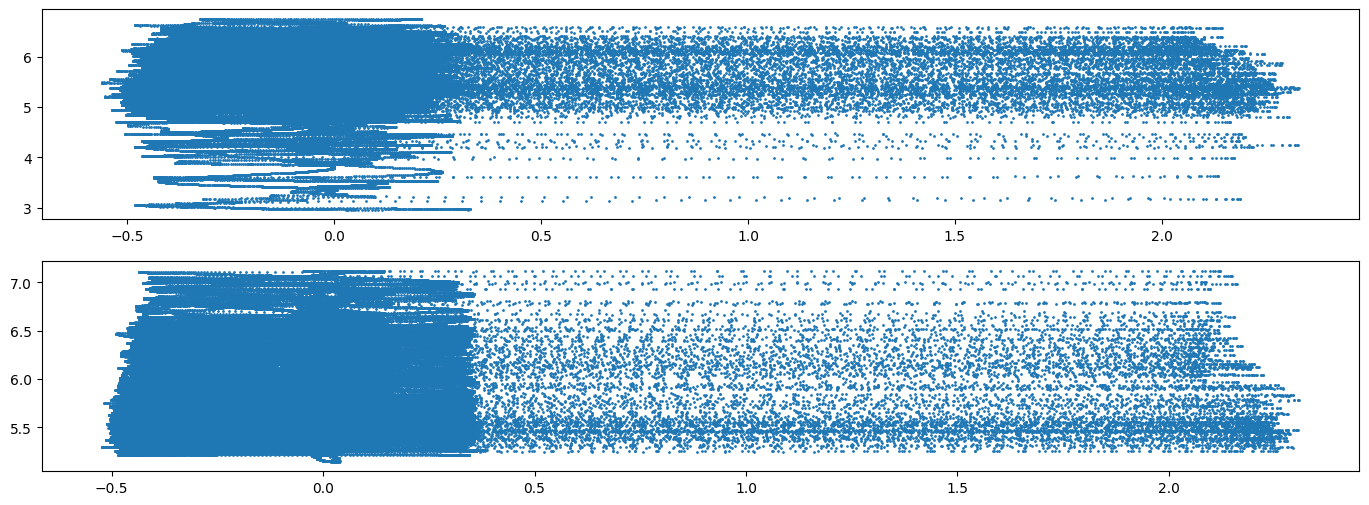

In [11]:
plt.figure(figsize=(17, 6))
plt.subplot(2, 1, 1)
plt.scatter(arr1ecg, arr1rsp, label='First Real', s=1)
plt.subplot(2, 1, 2)
plt.scatter(arr2ecg, arr2rsp, label='Second Real', s=1)

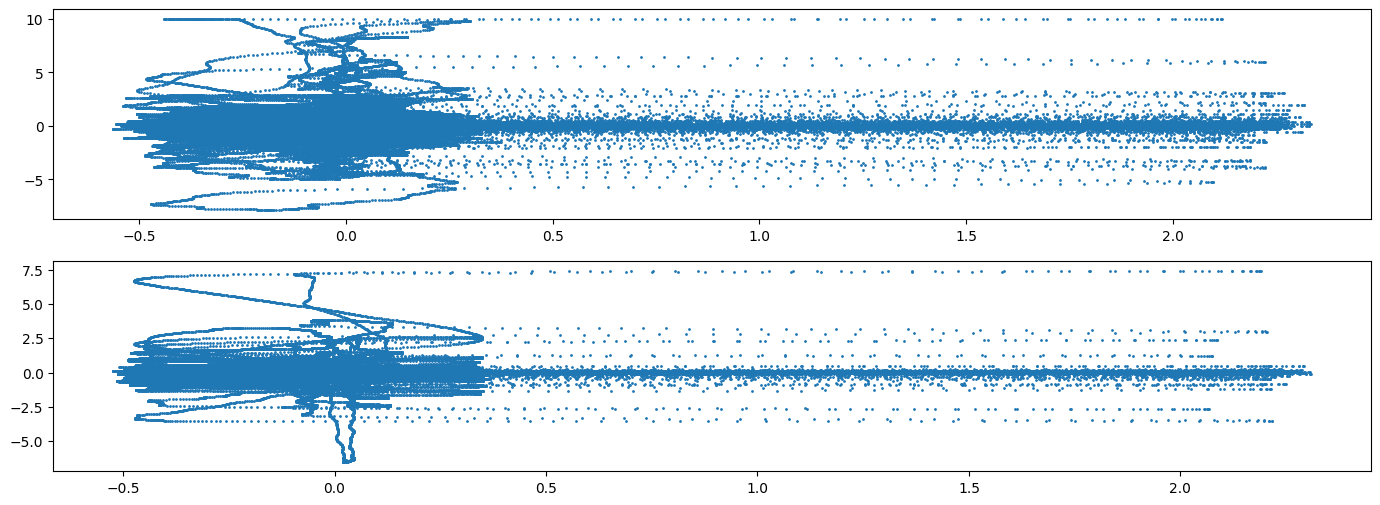

In [12]:
plt.figure(figsize=(17, 6))
plt.subplot(2, 1, 1)
plt.scatter(arr1ecg, arr1ppg, label='First Real', s=1)
plt.subplot(2, 1, 2)
plt.scatter(arr2ecg, arr2ppg, label='Second Real', s=1)

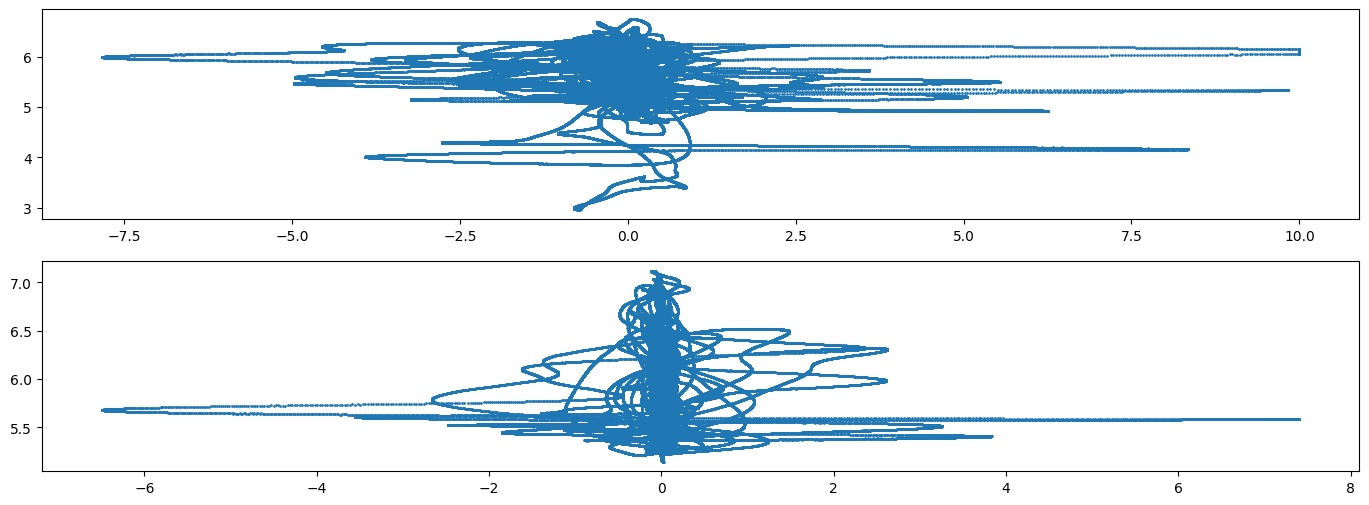

In [13]:
plt.figure(figsize=(17, 6))
plt.subplot(2, 1, 1)
plt.scatter(arr1ppg, arr1rsp, label='First Real', s=1)
plt.subplot(2, 1, 2)
plt.scatter(arr2ppg, arr2rsp, label='Second Real', s=1)

In [14]:
arrecg = np.concatenate((arr1ecg, arr2ecg))
arrppg = np.concatenate((arr1ppg, arr2ppg))
arrrsp = np.concatenate((arr1rsp, arr2rsp))

In [17]:
X = np.stack((arrecg, arrrsp))
print(X)
Y = arrppg
print(Y)

xtrain, xtest, ytrain, ytest = train_test_split(X.T, Y, test_size=0.1, random_state=42)

[[-4.73022e-03 -4.88281e-03 -4.73022e-03 ...  1.02234e-02  1.17493e-02
   1.23596e-02]
 [ 5.32043e+00  5.32104e+00  5.31982e+00 ...  5.30151e+00  5.30090e+00
   5.30151e+00]]
[-0.0143433 -0.0146484 -0.0146484 ... -0.0335693 -0.0338745 -0.0341797]


In [27]:
regr = linear_model.LinearRegression()
regr.fit(xtrain, ytrain)
print(xtest[0:1])
print(regr.predict(xtest[0:1]))

[[-0.373383  5.46265 ]]
[0.05103836]


In [ ]:
def checkValidity(ecg, rsp, ppg):
    pred = regr.predict([[ecg, rsp]])
    print(pred)
    if abs(pred - ppg) < 0.1:
        return 1
    else:
        return 0

In [32]:
correct = 0
for i in range(xtest.shape[0]):
    correct += checkValidity(xtest[i][0], xtest[i][1], ytest[i])


[0.05103836]
[0.07586938]
[0.06879124]
[-0.04692059]
[0.09466814]
[-0.0093973]
[0.06216812]
[-0.02941652]
[0.01790676]
[-0.01518929]
[0.02618158]
[-0.04294487]
[0.08140784]
[-0.05531389]
[-0.06162461]
[0.00468214]
[0.01863182]
[0.06514093]
[0.02033257]
[0.06541823]
[-0.0337391]
[0.03523971]
[-0.06471603]
[0.06349353]
[0.04709718]
[-0.08688164]
[0.06226596]
[-0.0498818]
[-0.05512738]
[0.01515742]
[0.08194377]
[-0.08477548]
[0.05502591]
[-0.01080794]
[0.05415237]
[-0.0240289]
[0.02082815]
[-0.08473741]
[0.07229322]
[0.10832237]
[0.02727106]
[-0.07641097]
[0.09792816]
[0.0533551]
[0.06367582]
[-0.14441262]
[-0.04257252]
[-0.10349377]
[-0.1538456]
[0.08011943]
[0.15139692]
[-0.07879388]
[0.01758524]
[0.05902002]
[0.08099068]
[0.08612209]
[0.10467689]
[0.07446822]
[0.00385056]
[-0.09413694]
[-0.04954819]
[0.09797756]
[-0.07049194]
[0.01347326]
[-0.01390491]
[-0.12491559]
[0.29212116]
[0.05217981]
[0.07282552]
[0.08262854]
[-0.00092024]
[-0.04597615]
[0.02352347]
[0.095161]
[-0.18124891]
[0.

In [34]:
print(correct/xtest.shape[0])

0.5149788193703715
